# ProfitPilot Colab T4 5m PPO Training

This notebook is built for a Colab T4 GPU kernel. It downloads BTC/USDT and ETH/USDT 5-minute candles from `2024-01-01` through `2026-04-20`, trains the RL trading model on the 2024-2025 portion, and tests out of sample on `2026-01-01` through `2026-04-20`.

The out-of-sample test is intentional: training and testing on the same candles would make the result look better than it really is. After the test metrics look acceptable, the optional final cell can retrain on the full requested window for a deployment-style artifact.

In [1]:
# Colab setup. This keeps Colab's CUDA PyTorch build intact and installs only the project dependencies.
%pip install -q stable-baselines3 sb3-contrib gymnasium ccxt ta python-dotenv pyyaml pyarrow seaborn tqdm rich

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.6/142.6 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 111.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 kB 26.3 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import json
import math
import os
import random
import sys
import warnings

try:
    from google.colab import drive

    if Path('/content').exists() and not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
except Exception as exc:
    print(f'Google Drive mount skipped: {exc}')

project_candidates = []
env_root = os.environ.get('PROFIT_PILOT_ROOT')
if env_root:
    project_candidates.append(Path(env_root).expanduser())
project_candidates.extend([
    Path.cwd(),
    Path('/content/drive/MyDrive/ProfitPilot'),
    Path('/content/drive/My Drive/ProfitPilot'),
])

PROJECT_ROOT = None
for candidate in project_candidates:
    if candidate and (candidate / 'src' / 'profit_pilot').exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Could not find ProfitPilot. Set PROFIT_PILOT_ROOT to your Drive project path, '
        'for example /content/drive/MyDrive/ProfitPilot.'
    )

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Project root: {PROJECT_ROOT}')

import numpy as np
import pandas as pd
import torch
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA GPU not detected. Select a Colab T4 GPU runtime/kernel before training for best speed.')

Mounted at /content/drive
Project root: /content/drive/MyDrive/ProfitPilot
PyTorch device: cuda
GPU: Tesla T4


In [5]:
import ccxt
import matplotlib.pyplot as plt
import seaborn as sns
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.utils import set_random_seed
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

from profit_pilot.data.download_ohlcv import fetch_symbol_ohlcv, save_symbol_csv
from profit_pilot.env.multi_crypto_env import MultiCryptoTradingEnv
from profit_pilot.features.build_features import (
    BASE_FEATURE_COLUMNS,
    add_technical_indicators,
    align_frames,
    build_arrays,
)
from profit_pilot.utils.io import bundle_directory, save_json, symbol_slug

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_random_seed(SEED)

# Binance is blocked from some Colab locations with HTTP 451, so the download cell tries these in order.
EXCHANGE_IDS = [
    exchange_id.strip()
    for exchange_id in os.environ.get('PROFIT_PILOT_EXCHANGES', 'binanceus,kucoin,okx,bybit,binance').split(',')
    if exchange_id.strip()
]
EXCHANGE_ID = EXCHANGE_IDS[0]
SYMBOLS = ['BTC/USDT', 'ETH/USDT']
TIMEFRAME = '5m'
DOWNLOAD_LIMIT = 1000

DATA_START_ISO = '2024-01-01T00:00:00Z'
TEST_START_ISO = '2026-01-01T00:00:00Z'
DATA_END_ISO = '2026-04-20T23:55:00Z'

INITIAL_CASH = 10_000.0
LOOKBACK = 96
TOTAL_TIMESTEPS = 300_000
TRAIN_MODEL = True
USE_LSTM = False
FORCE_REDOWNLOAD = False
RUN_FINAL_FULL_WINDOW_RETRAIN = False

RAW_ROOT = PROJECT_ROOT / 'data' / 'raw_colab_5m_2024_2026'
PROCESSED_TRAIN_ROOT = PROJECT_ROOT / 'data' / 'processed_colab_5m_train_2024_2025'
PROCESSED_TEST_ROOT = PROJECT_ROOT / 'data' / 'processed_colab_5m_test_2026_0420'
PROCESSED_FULL_ROOT = PROJECT_ROOT / 'data' / 'processed_colab_5m_full_2024_2026'
MODEL_DIR = PROJECT_ROOT / 'models' / 'colab_5m_2024_2026'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'colab_5m_2024_2026'
PLOT_DIR = REPORT_DIR / 'plots'
for path in [RAW_ROOT, PROCESSED_TRAIN_ROOT, PROCESSED_TEST_ROOT, PROCESSED_FULL_ROOT, MODEL_DIR, REPORT_DIR, PLOT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_NAME = f"profit_pilot_{'recurrent_' if USE_LSTM else ''}ppo_5m_t4"
MODEL_PATH = MODEL_DIR / MODEL_NAME

print(f'Exchange fallback order: {EXCHANGE_IDS}')
print(f'Model name: {MODEL_NAME}')
print(f'Reports: {REPORT_DIR}')

Exchange fallback order: ['binanceus', 'kucoin', 'okx', 'bybit', 'binance']
Model name: profit_pilot_ppo_5m_t4
Reports: /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026


## Download and Cache 5m Market Data

This cell uses public OHLCV candles through CCXT. Colab often receives Binance HTTP 451 from restricted cloud locations, so the notebook automatically tries the fallback exchanges from `EXCHANGE_IDS` and uses the first one that works for all symbols.

In [6]:
def create_market_data_exchange(exchange_id: str):
    exchange_class = getattr(ccxt, exchange_id)
    exchange = exchange_class({'enableRateLimit': True})
    exchange.timeout = 30_000
    return exchange


def read_cached_frame(path: Path) -> pd.DataFrame | None:
    if not path.exists() or FORCE_REDOWNLOAD:
        return None

    frame = pd.read_csv(path)
    if frame.empty or 'datetime' not in frame.columns:
        return None

    frame['datetime'] = pd.to_datetime(frame['datetime'], utc=True)
    start = pd.Timestamp(DATA_START_ISO)
    end = pd.Timestamp(DATA_END_ISO)
    if frame['datetime'].min() <= start and frame['datetime'].max() >= end - pd.Timedelta(minutes=5):
        return frame[(frame['datetime'] >= start) & (frame['datetime'] <= end)].copy()
    return None


def load_or_download_symbol(exchange, exchange_id: str, symbol: str) -> pd.DataFrame:
    target_path = RAW_ROOT / exchange_id / TIMEFRAME / f'{symbol_slug(symbol)}.csv'
    cached = read_cached_frame(target_path)
    if cached is not None:
        print(f'Using cached {symbol} from {exchange_id}: {len(cached):,} rows')
        return cached

    print(f'Downloading {symbol} {TIMEFRAME} from {exchange_id}: {DATA_START_ISO} to {DATA_END_ISO}')
    frame = fetch_symbol_ohlcv(
        exchange=exchange,
        symbol=symbol,
        timeframe=TIMEFRAME,
        since=DATA_START_ISO,
        until=DATA_END_ISO,
        limit=DOWNLOAD_LIMIT,
    )
    frame['datetime'] = pd.to_datetime(frame['datetime'], utc=True)
    saved_path = save_symbol_csv(frame, RAW_ROOT, exchange_id, TIMEFRAME, symbol)
    print(f'Saved {len(frame):,} rows to {saved_path}')
    return frame


def download_all_symbols_from_exchange(exchange_id: str) -> dict[str, pd.DataFrame]:
    exchange = create_market_data_exchange(exchange_id)
    try:
        exchange.load_markets()
        available_symbols = set(exchange.symbols or [])
        missing_symbols = [symbol for symbol in SYMBOLS if symbol not in available_symbols]
        if missing_symbols:
            raise ValueError(f'{exchange_id} does not list these symbols: {missing_symbols}')

        return {
            symbol: load_or_download_symbol(exchange, exchange_id, symbol)
            for symbol in SYMBOLS
        }
    finally:
        if hasattr(exchange, 'close'):
            exchange.close()


full_symbol_frames = None
download_errors = {}
for candidate_exchange_id in EXCHANGE_IDS:
    print(f'\nTrying exchange: {candidate_exchange_id}')
    try:
        candidate_frames = download_all_symbols_from_exchange(candidate_exchange_id)
        full_symbol_frames = candidate_frames
        EXCHANGE_ID = candidate_exchange_id
        print(f'Using exchange for this run: {EXCHANGE_ID}')
        break
    except Exception as exc:
        error_message = f'{type(exc).__name__}: {str(exc)}'
        download_errors[candidate_exchange_id] = error_message
        print(f'{candidate_exchange_id} failed: {error_message[:500]}')

if full_symbol_frames is None:
    display(pd.DataFrame(download_errors.items(), columns=['exchange', 'error']))
    raise RuntimeError(
        'No exchange in EXCHANGE_IDS could download all requested symbols. '
        'Try changing EXCHANGE_IDS in Cell 4, for example to ["kucoin", "okx", "bybit"].'
    )

coverage_rows = []
for symbol, frame in full_symbol_frames.items():
    coverage_rows.append({
        'exchange': EXCHANGE_ID,
        'symbol': symbol,
        'rows': len(frame),
        'first': frame['datetime'].min(),
        'last': frame['datetime'].max(),
    })
display(pd.DataFrame(coverage_rows))


Trying exchange: binanceus
Saved 242,208 rows to /content/drive/MyDrive/ProfitPilot/data/raw_colab_5m_2024_2026/binanceus/5m/btc_usdt.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saved 242,208 rows to /content/drive/MyDrive/ProfitPilot/data/raw_colab_5m_2024_2026/binanceus/5m/eth_usdt.csv
Using exchange for this run: binanceus


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,exchange,symbol,rows,first,last
0,binanceus,BTC/USDT,242208,2024-01-01 00:00:00+00:00,2026-04-20 23:55:00+00:00
1,binanceus,ETH/USDT,242208,2024-01-01 00:00:00+00:00,2026-04-20 23:55:00+00:00


## Build Train and Test Feature Bundles

Technical features are standardized with train-set statistics only. The same train mean and standard deviation are then applied to the test set, which avoids leaking future information from the test period into training.

In [7]:
def split_symbol_frames(frames: dict[str, pd.DataFrame], start_iso: str, end_iso: str, inclusive_end: bool) -> dict[str, pd.DataFrame]:
    start = pd.Timestamp(start_iso)
    end = pd.Timestamp(end_iso)
    split_frames = {}
    for symbol, frame in frames.items():
        working = frame.copy()
        working['datetime'] = pd.to_datetime(working['datetime'], utc=True)
        if inclusive_end:
            mask = (working['datetime'] >= start) & (working['datetime'] <= end)
        else:
            mask = (working['datetime'] >= start) & (working['datetime'] < end)
        split = working.loc[mask].sort_values('datetime').reset_index(drop=True)
        if split.empty:
            raise ValueError(f'No rows for {symbol} between {start_iso} and {end_iso}')
        split_frames[symbol] = split
    return split_frames


def build_normalized_feature_bundle(
    symbol_frames: dict[str, pd.DataFrame],
    processed_root: Path,
    source_start_iso: str,
    source_end_iso: str,
    label: str,
    normalization_stats: dict[str, np.ndarray] | None = None,
) -> tuple[dict, dict[str, np.ndarray]]:
    enriched_frames = {}
    for symbol, frame in symbol_frames.items():
        enriched = add_technical_indicators(frame)
        if enriched.empty:
            raise ValueError(f'Feature frame became empty after indicator warm-up: {symbol}')
        enriched_frames[symbol] = enriched

    timestamps, aligned_frames = align_frames(enriched_frames)
    price_array, raw_tech_array, feature_export = build_arrays(SYMBOLS, aligned_frames)

    if normalization_stats is None:
        tech_mean = raw_tech_array.mean(axis=0)
        tech_std = raw_tech_array.std(axis=0)
        tech_std = np.where(tech_std < 1e-8, 1.0, tech_std)
        normalization_stats = {'mean': tech_mean, 'std': tech_std}

    tech_array = ((raw_tech_array - normalization_stats['mean']) / normalization_stats['std']).astype(np.float32)
    price_array = price_array.astype(np.float32)

    output_dir = bundle_directory(processed_root, TIMEFRAME, SYMBOLS)
    output_dir.mkdir(parents=True, exist_ok=True)
    np.save(output_dir / 'price_array.npy', price_array)
    np.save(output_dir / 'tech_array.npy', tech_array)
    np.save(output_dir / 'tech_mean.npy', normalization_stats['mean'])
    np.save(output_dir / 'tech_std.npy', normalization_stats['std'])
    pd.DataFrame({'datetime': timestamps.astype(str)}).to_csv(output_dir / 'timestamps.csv', index=False)
    feature_export.to_parquet(output_dir / 'feature_frame.parquet', index=False)

    metadata = {
        'label': label,
        'symbols': SYMBOLS,
        'feature_columns_per_asset': BASE_FEATURE_COLUMNS,
        'n_assets': len(SYMBOLS),
        'n_features_per_asset': len(BASE_FEATURE_COLUMNS),
        'price_array_shape': list(price_array.shape),
        'tech_array_shape': list(tech_array.shape),
        'timeframe': TIMEFRAME,
        'source_since': source_start_iso,
        'source_until': source_end_iso,
        'first_timestamp_after_warmup': str(timestamps.min()),
        'last_timestamp': str(timestamps.max()),
        'normalization': 'standard_score_using_train_stats',
    }
    save_json(metadata, output_dir / 'metadata.json')

    bundle = {
        'root': output_dir,
        'price_array': price_array,
        'tech_array': tech_array,
        'timestamps': pd.DataFrame({'datetime': timestamps.astype(str)}),
        'metadata': metadata,
    }
    return bundle, normalization_stats


train_frames = split_symbol_frames(full_symbol_frames, DATA_START_ISO, TEST_START_ISO, inclusive_end=False)
test_frames = split_symbol_frames(full_symbol_frames, TEST_START_ISO, DATA_END_ISO, inclusive_end=True)

train_bundle, train_norm_stats = build_normalized_feature_bundle(
    train_frames,
    PROCESSED_TRAIN_ROOT,
    DATA_START_ISO,
    TEST_START_ISO,
    label='train_2024_2025',
)
test_bundle, _ = build_normalized_feature_bundle(
    test_frames,
    PROCESSED_TEST_ROOT,
    TEST_START_ISO,
    DATA_END_ISO,
    label='test_2026_0101_0420',
    normalization_stats=train_norm_stats,
)

bundle_summary = pd.DataFrame([train_bundle['metadata'], test_bundle['metadata']])
display(bundle_summary[[
    'label',
    'timeframe',
    'source_since',
    'source_until',
    'first_timestamp_after_warmup',
    'last_timestamp',
    'price_array_shape',
    'tech_array_shape',
]])

,label,timeframe,source_since,source_until,first_timestamp_after_warmup,last_timestamp,price_array_shape,tech_array_shape
0,train_2024_2025,5m,2024-01-01T00:00:00Z,2026-01-01T00:00:00Z,2024-01-01 02:45:00+00:00,2025-12-31 23:55:00+00:00,"[210494, 2]","[210494, 22]"
1,test_2026_0101_0420,5m,2026-01-01T00:00:00Z,2026-04-20T23:55:00Z,2026-01-01 02:45:00+00:00,2026-04-20 23:55:00+00:00,"[31647, 2]","[31647, 22]"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Train PPO on the T4 GPU

The environment simulation still runs on CPU, while the neural network training runs on CUDA when the T4 is available. For a more serious run, increase `TOTAL_TIMESTEPS` to `1_000_000` or more after the first end-to-end test works.

In [8]:
ENV_KWARGS = dict(
    lookback=LOOKBACK,
    initial_cash=INITIAL_CASH,
    buy_cost_pct=0.001,
    sell_cost_pct=0.001,
    cash_norm=0.0001,
    holdings_norm=1.0,
    tech_norm=1.0,
    reward_scaling=1.0,
    reward_mode='return_cost_risk_volatility',
    cost_penalty_weight=1.0,
    risk_penalty_weight=0.005,
    volatility_reward_weight=0.01,
    volatility_window=288,
    risk_adjusted_return_clip=5.0,
    max_position_fraction=0.50,
    max_trade_fraction=0.25,
    stop_loss_pct=0.08,
    max_drawdown_pct=0.20,
    min_trade_quantity=0.0001,
    cooldown_steps=0,
)


def make_trading_env(bundle: dict) -> MultiCryptoTradingEnv:
    if bundle['price_array'].shape[0] <= LOOKBACK + 2:
        raise ValueError('Not enough rows for the configured LOOKBACK.')
    return MultiCryptoTradingEnv(
        price_array=bundle['price_array'],
        tech_array=bundle['tech_array'],
        tickers=SYMBOLS,
        **ENV_KWARGS,
    )


def make_vec_env(bundle: dict):
    def _make_env():
        return make_trading_env(bundle)

    return VecMonitor(DummyVecEnv([_make_env]))


train_env = make_vec_env(train_bundle)
print(f'Observation shape: {train_env.observation_space.shape}')
print(f'Action shape: {train_env.action_space.shape}')

Observation shape: (2115,)
Action shape: (2,)


In [9]:
checkpoint_callback = CheckpointCallback(
    save_freq=50_000,
    save_path=str(MODEL_DIR / 'checkpoints'),
    name_prefix=MODEL_NAME,
)

common_model_kwargs = dict(
    env=train_env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=4096,
    batch_size=1024,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    device=DEVICE,
    tensorboard_log=str(REPORT_DIR / 'tensorboard'),
)

if TRAIN_MODEL:
    if USE_LSTM:
        model = RecurrentPPO('MlpLstmPolicy', **common_model_kwargs)
    else:
        model = PPO('MlpPolicy', policy_kwargs={'net_arch': [256, 256]}, **common_model_kwargs)

    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=checkpoint_callback, progress_bar=True)
    model.save(MODEL_PATH)
    train_env.close()

    training_summary = {
        'model_path': str(MODEL_PATH) + '.zip',
        'model_name': MODEL_NAME,
        'use_lstm': USE_LSTM,
        'device': DEVICE,
        'total_timesteps': TOTAL_TIMESTEPS,
        'symbols': SYMBOLS,
        'timeframe': TIMEFRAME,
        'train_window': [DATA_START_ISO, TEST_START_ISO],
        'test_window': [TEST_START_ISO, DATA_END_ISO],
        'lookback': LOOKBACK,
        'train_price_array_shape': list(train_bundle['price_array'].shape),
        'train_tech_array_shape': list(train_bundle['tech_array'].shape),
    }
    save_json(training_summary, MODEL_DIR / f'{MODEL_NAME}_training_summary.json')
else:
    model_class = RecurrentPPO if USE_LSTM else PPO
    model = model_class.load(MODEL_PATH, device=DEVICE)
    train_env.close()

print(f'Model ready: {MODEL_PATH}.zip')

Using cuda device
Logging to /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026/tensorboard/PPO_1


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------
| time/              |      |
|    fps             | 432  |
|    iterations      | 1    |
|    time_elapsed    | 9    |
|    total_timesteps | 4096 |
-----------------------------


...

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 1.4e+05    |
|    ep_rew_mean          | -47.8      |
| time/                   |            |
|    fps                  | 435        |
|    iterations           | 71         |
|    time_elapsed         | 667        |
|    total_timesteps      | 290816     |
| train/                  |            |
|    approx_kl            | 0.15414038 |
|    clip_fraction        | 0.458      |
|    clip_range           | 0.2        |
|    entropy_loss         | -2.03      |
|    explained_variance   | -0.164     |
|    learning_rate        | 0.0003     |
|    loss                 | -0.126     |
|    n_updates            | 700        |
|    policy_gradient_loss | -0.0695    |
|    std                  | 0.665      |
|    value_loss           | 0.000169   |
----------------------------------------


---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 1.4e+05   |
|    ep_rew_mean          | -47.8     |
| time/                   |           |
|    fps                  | 435       |
|    iterations           | 72        |
|    time_elapsed         | 677       |
|    total_timesteps      | 294912    |
| train/                  |           |
|    approx_kl            | 0.0909128 |
|    clip_fraction        | 0.398     |
|    clip_range           | 0.2       |
|    entropy_loss         | -2.02     |
|    explained_variance   | -0.0893   |
|    learning_rate        | 0.0003    |
|    loss                 | -0.097    |
|    n_updates            | 710       |
|    policy_gradient_loss | -0.0493   |
|    std                  | 0.663     |
|    value_loss           | 9.81e-05  |
---------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.4e+05     |
|    ep_rew_mean          | -47.8       |
| time/                   |             |
|    fps                  | 435         |
|    iterations           | 73          |
|    time_elapsed         | 686         |
|    total_timesteps      | 299008      |
| train/                  |             |
|    approx_kl            | 0.107897826 |
|    clip_fraction        | 0.454       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.01       |
|    explained_variance   | -0.0333     |
|    learning_rate        | 0.0003      |
|    loss                 | -0.124      |
|    n_updates            | 720         |
|    policy_gradient_loss | -0.0585     |
|    std                  | 0.661       |
|    value_loss           | 0.000243    |
-----------------------------------------


---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 1.4e+05   |
|    ep_rew_mean          | -47.8     |
| time/                   |           |
|    fps                  | 435       |
|    iterations           | 74        |
|    time_elapsed         | 696       |
|    total_timesteps      | 303104    |
| train/                  |           |
|    approx_kl            | 0.2056866 |
|    clip_fraction        | 0.497     |
|    clip_range           | 0.2       |
|    entropy_loss         | -2        |
|    explained_variance   | -0.307    |
|    learning_rate        | 0.0003    |
|    loss                 | -0.143    |
|    n_updates            | 730       |
|    policy_gradient_loss | -0.0848   |
|    std                  | 0.654     |
|    value_loss           | 0.000429  |
---------------------------------------


Model ready: /content/drive/MyDrive/ProfitPilot/models/colab_5m_2024_2026/profit_pilot_ppo_5m_t4.zip


## Evaluate the Model Out of Sample

The test episode uses deterministic actions and compares the agent against the environment's equal-weight buy-and-hold benchmark.

In [10]:
def make_eval_record(env: MultiCryptoTradingEnv, timestamps: pd.Series, step: int, reward: float, action, info: dict) -> dict:
    action_array = np.zeros(len(SYMBOLS), dtype=np.float32) if action is None else np.asarray(action, dtype=np.float32).reshape(-1)
    record = {
        'step': step,
        'datetime': pd.to_datetime(timestamps.iloc[env.time], utc=True),
        'portfolio_value': float(env.portfolio_value),
        'benchmark_value': float(info.get('benchmark_value', env.equal_weight_value)),
        'cash': float(env.cash),
        'reward': float(reward),
        'portfolio_return': float(info.get('portfolio_return', 0.0)),
        'drawdown': float(info.get('drawdown', 0.0)),
        'total_fees': float(info.get('total_fees', 0.0)),
        'rolling_volatility': float(info.get('rolling_volatility', 0.0)),
        'risk_adjusted_return': float(info.get('risk_adjusted_return', 0.0)),
        'cost_penalty': float(info.get('cost_penalty', 0.0)),
        'risk_halted': bool(info.get('risk_halted', False)),
    }
    for index, symbol in enumerate(SYMBOLS):
        slug = symbol_slug(symbol)
        price = float(env.price_array[env.time, index])
        holding = float(env.holdings[index])
        record[f'price_{slug}'] = price
        record[f'holding_{slug}'] = holding
        record[f'position_value_{slug}'] = holding * price
        record[f'action_{slug}'] = float(action_array[index]) if index < len(action_array) else 0.0
    return record


def evaluate_trading_model(model, bundle: dict, label: str) -> pd.DataFrame:
    env = make_trading_env(bundle)
    timestamps = pd.to_datetime(bundle['timestamps']['datetime'], utc=True)
    observation, info = env.reset()

    records = [make_eval_record(env, timestamps, step=0, reward=0.0, action=None, info=info)]
    done = False
    step = 0
    lstm_state = None
    episode_start = np.array([True], dtype=bool)

    while not done:
        if USE_LSTM:
            action, lstm_state = model.predict(
                observation,
                state=lstm_state,
                episode_start=episode_start,
                deterministic=True,
            )
        else:
            action, _ = model.predict(observation, deterministic=True)

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        step += 1
        records.append(make_eval_record(env, timestamps, step=step, reward=reward, action=action, info=info))
        episode_start = np.array([done], dtype=bool)

    result = pd.DataFrame(records)
    result['label'] = label
    return result


test_results = evaluate_trading_model(model, test_bundle, label='test_2026_0101_0420')
test_csv_path = REPORT_DIR / f'{MODEL_NAME}_test_results.csv'
test_results.to_csv(test_csv_path, index=False)
display(test_results.head())
display(test_results.tail())
print(f'Saved test results: {test_csv_path}')

,step,datetime,portfolio_value,benchmark_value,cash,reward,portfolio_return,drawdown,total_fees,rolling_volatility,...,risk_halted,price_btc_usdt,holding_btc_usdt,position_value_btc_usdt,action_btc_usdt,price_eth_usdt,holding_eth_usdt,position_value_eth_usdt,action_eth_usdt,label
0,0,2026-01-01 10:40:00+00:00,10000.000000,10000.000000,10000.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,...,False,87849.648438,0.0,0.0,0.000000,2979.389893,0.000000,0.000000,0.000000,test_2026_0101_0420
1,1,2026-01-01 10:45:00+00:00,9999.999023,10000.000000,9998.774985,-1.342741e-06,-9.765625e-08,9.765625e-08,0.001224,0.000870,...,False,87849.648438,0.0,0.0,1.000000,2979.389893,0.000411,1.223791,0.410752,test_2026_0101_0420
2,2,2026-01-01 10:50:00+00:00,10000.000977,10008.088867,9998.774985,2.430908e-06,1.953125e-07,0.000000e+00,0.000000,0.000874,...,False,87849.648438,0.0,0.0,0.519098,2984.209961,0.000411,1.225771,-0.048108,test_2026_0101_0420
3,3,2026-01-01 10:55:00+00:00,9999.999023,10009.339844,9999.999469,-2.565259e-06,-1.953125e-07,1.953125e-07,0.001226,0.000869,...,False,87876.046875,0.0,0.0,0.413332,2984.060059,0.000000,0.000000,-0.550833,test_2026_0101_0420
4,4,2026-01-01 11:00:00+00:00,9999.999023,10011.972656,9999.999469,-9.765624e-10,0.000000e+00,1.953125e-07,0.000000,0.000866,...,False,87870.710938,0.0,0.0,0.558909,2985.810059,0.000000,0.000000,-0.538609,test_2026_0101_0420


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,step,datetime,portfolio_value,benchmark_value,cash,reward,portfolio_return,drawdown,total_fees,rolling_volatility,...,risk_halted,price_btc_usdt,holding_btc_usdt,position_value_btc_usdt,action_btc_usdt,price_eth_usdt,holding_eth_usdt,position_value_eth_usdt,action_eth_usdt,label
31547,31547,2026-04-20 23:35:00+00:00,10179.113281,8195.747070,5089.554792,0.005055,0.000795,0.030439,0.002181,0.001679,...,False,75770.367188,0.0,0.0,-1.0,2313.939941,2.199520,5089.557989,0.971006,test_2026_0101_0420
31548,31548,2026-04-20 23:40:00+00:00,10181.310547,8199.959961,5090.654765,0.001343,0.000216,0.030230,0.001101,0.001679,...,False,75814.898438,0.0,0.0,-1.0,2314.939941,2.199045,5090.656419,1.000000,test_2026_0101_0420
31549,31549,2026-04-20 23:45:00+00:00,10181.310547,8204.033203,5090.654765,-0.000151,0.000000,0.030230,0.000000,0.001677,...,False,75886.453125,0.0,0.0,-1.0,2314.939941,2.199045,5090.656419,1.000000,test_2026_0101_0420
31550,31550,2026-04-20 23:50:00+00:00,10181.310547,8204.033203,5090.654765,-0.000151,0.000000,0.030230,0.000000,0.001675,...,False,75886.453125,0.0,0.0,-1.0,2314.939941,2.199045,5090.656419,1.000000,test_2026_0101_0420
31551,31551,2026-04-20 23:55:00+00:00,10179.177734,8200.527344,5089.588270,-0.001608,-0.000209,0.030433,0.001065,0.001672,...,False,75853.476562,0.0,0.0,-1.0,2313.969971,2.199505,5089.588730,1.000000,test_2026_0101_0420


Saved test results: /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026/profit_pilot_ppo_5m_t4_test_results.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Metrics for Worthiness Check

These metrics are research diagnostics, not financial advice. A useful model should beat the equal-weight benchmark after fees, avoid worse drawdown, and show a better risk-adjusted return on the out-of-sample test.

In [11]:
PERIODS_PER_YEAR = 365 * 24 * 12
RETURN_EPS = 1e-12


def add_curve_columns(frame: pd.DataFrame) -> pd.DataFrame:
    enriched = frame.copy()
    enriched['agent_return'] = enriched['portfolio_value'].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    enriched['benchmark_return'] = enriched['benchmark_value'].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    enriched['agent_cumulative_return'] = enriched['portfolio_value'] / enriched['portfolio_value'].iloc[0] - 1.0
    enriched['benchmark_cumulative_return'] = enriched['benchmark_value'] / enriched['benchmark_value'].iloc[0] - 1.0
    enriched['agent_drawdown'] = enriched['portfolio_value'] / enriched['portfolio_value'].cummax() - 1.0
    enriched['benchmark_drawdown'] = enriched['benchmark_value'] / enriched['benchmark_value'].cummax() - 1.0
    position_cols = [f'position_value_{symbol_slug(symbol)}' for symbol in SYMBOLS]
    enriched['gross_exposure'] = enriched[position_cols].sum(axis=1) / enriched['portfolio_value'].clip(lower=RETURN_EPS)
    for symbol in SYMBOLS:
        slug = symbol_slug(symbol)
        enriched[f'exposure_{slug}'] = enriched[f'position_value_{slug}'] / enriched['portfolio_value'].clip(lower=RETURN_EPS)
    return enriched


def annualized_return(values: pd.Series, timestamps: pd.Series) -> float:
    elapsed_seconds = max((timestamps.iloc[-1] - timestamps.iloc[0]).total_seconds(), 1.0)
    years = elapsed_seconds / (365 * 24 * 60 * 60)
    return float((values.iloc[-1] / max(values.iloc[0], RETURN_EPS)) ** (1 / years) - 1)


def sharpe_ratio(returns: pd.Series) -> float:
    std = returns.std(ddof=0)
    if std <= RETURN_EPS:
        return 0.0
    return float((returns.mean() / std) * math.sqrt(PERIODS_PER_YEAR))


def sortino_ratio(returns: pd.Series) -> float:
    downside = returns[returns < 0]
    downside_std = downside.std(ddof=0)
    if downside_std <= RETURN_EPS or downside.empty:
        return 0.0
    return float((returns.mean() / downside_std) * math.sqrt(PERIODS_PER_YEAR))


def summarize_strategy(frame: pd.DataFrame, value_col: str, return_col: str, drawdown_col: str) -> dict:
    returns = frame[return_col]
    values = frame[value_col]
    max_drawdown = abs(float(frame[drawdown_col].min()))
    ann_return = annualized_return(values, frame['datetime'])
    ann_vol = float(returns.std(ddof=0) * math.sqrt(PERIODS_PER_YEAR))
    return {
        'initial_value': float(values.iloc[0]),
        'final_value': float(values.iloc[-1]),
        'total_return_pct': float((values.iloc[-1] / values.iloc[0] - 1.0) * 100),
        'annualized_return_pct': ann_return * 100,
        'annualized_volatility_pct': ann_vol * 100,
        'sharpe': sharpe_ratio(returns),
        'sortino': sortino_ratio(returns),
        'max_drawdown_pct': max_drawdown * 100,
        'calmar': float(ann_return / max(max_drawdown, RETURN_EPS)),
        'win_rate_pct': float((returns > 0).mean() * 100),
    }


test_results = add_curve_columns(test_results)
test_results.to_csv(test_csv_path, index=False)

holding_cols = [f'holding_{symbol_slug(symbol)}' for symbol in SYMBOLS]
trade_events = int((test_results[holding_cols].diff().abs().sum(axis=1) > 1e-8).sum())

agent_metrics = summarize_strategy(test_results, 'portfolio_value', 'agent_return', 'agent_drawdown')
benchmark_metrics = summarize_strategy(test_results, 'benchmark_value', 'benchmark_return', 'benchmark_drawdown')
agent_metrics.update({
    'total_fees': float(test_results['total_fees'].sum()),
    'trade_events': trade_events,
    'mean_gross_exposure_pct': float(test_results['gross_exposure'].mean() * 100),
    'risk_halted': bool(test_results['risk_halted'].any()),
})
benchmark_metrics.update({
    'total_fees': 0.0,
    'trade_events': 0,
    'mean_gross_exposure_pct': 100.0,
    'risk_halted': False,
})

metrics_df = pd.DataFrame({'agent': agent_metrics, 'equal_weight_benchmark': benchmark_metrics}).T
metrics_df['alpha_vs_benchmark_pct'] = metrics_df['total_return_pct'] - metrics_df.loc['equal_weight_benchmark', 'total_return_pct']
display(metrics_df.round(4))

metrics_path = REPORT_DIR / f'{MODEL_NAME}_test_metrics.json'
metrics_payload = json.loads(metrics_df.reset_index().rename(columns={'index': 'strategy'}).to_json(orient='records'))
with metrics_path.open('w', encoding='utf-8') as handle:
    json.dump(metrics_payload, handle, indent=2)

agent = metrics_df.loc['agent']
benchmark = metrics_df.loc['equal_weight_benchmark']
passes_return = agent['total_return_pct'] > benchmark['total_return_pct']
passes_sharpe = agent['sharpe'] > benchmark['sharpe']
passes_drawdown = agent['max_drawdown_pct'] <= benchmark['max_drawdown_pct']
passes_positive = agent['total_return_pct'] > 0
score = sum([passes_return, passes_sharpe, passes_drawdown, passes_positive])
verdict = 'PASS for deeper research' if score >= 3 else 'NOT WORTH DEPLOYING YET'
print(f'Worthiness check: {verdict} ({score}/4 conditions passed)')
print(f'Saved enriched test results: {test_csv_path}')
print(f'Saved metrics: {metrics_path}')

,initial_value,final_value,total_return_pct,annualized_return_pct,annualized_volatility_pct,sharpe,sortino,max_drawdown_pct,calmar,win_rate_pct,total_fees,trade_events,mean_gross_exposure_pct,risk_halted,alpha_vs_benchmark_pct
agent,10000.0,10179.177734,1.791777,6.095452,20.993175,0.386705,0.467645,9.548302,0.638381,39.461841,58.036548,28246,25.028617,False,19.786504
equal_weight_benchmark,10000.0,8200.527344,-17.994727,-48.365203,61.159417,-0.775142,-0.99461,43.200417,-1.119554,47.737069,0.0,0,100.0,False,0.0


Worthiness check: PASS for deeper research (4/4 conditions passed)
Saved enriched test results: /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026/profit_pilot_ppo_5m_t4_test_results.csv
Saved metrics: /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026/profit_pilot_ppo_5m_t4_test_metrics.json


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Plots for Model Analysis

The key plots are equity curve, cumulative return, drawdown, exposure, actions, and return distribution. These are the first charts to inspect before deciding whether the trained policy is useful.

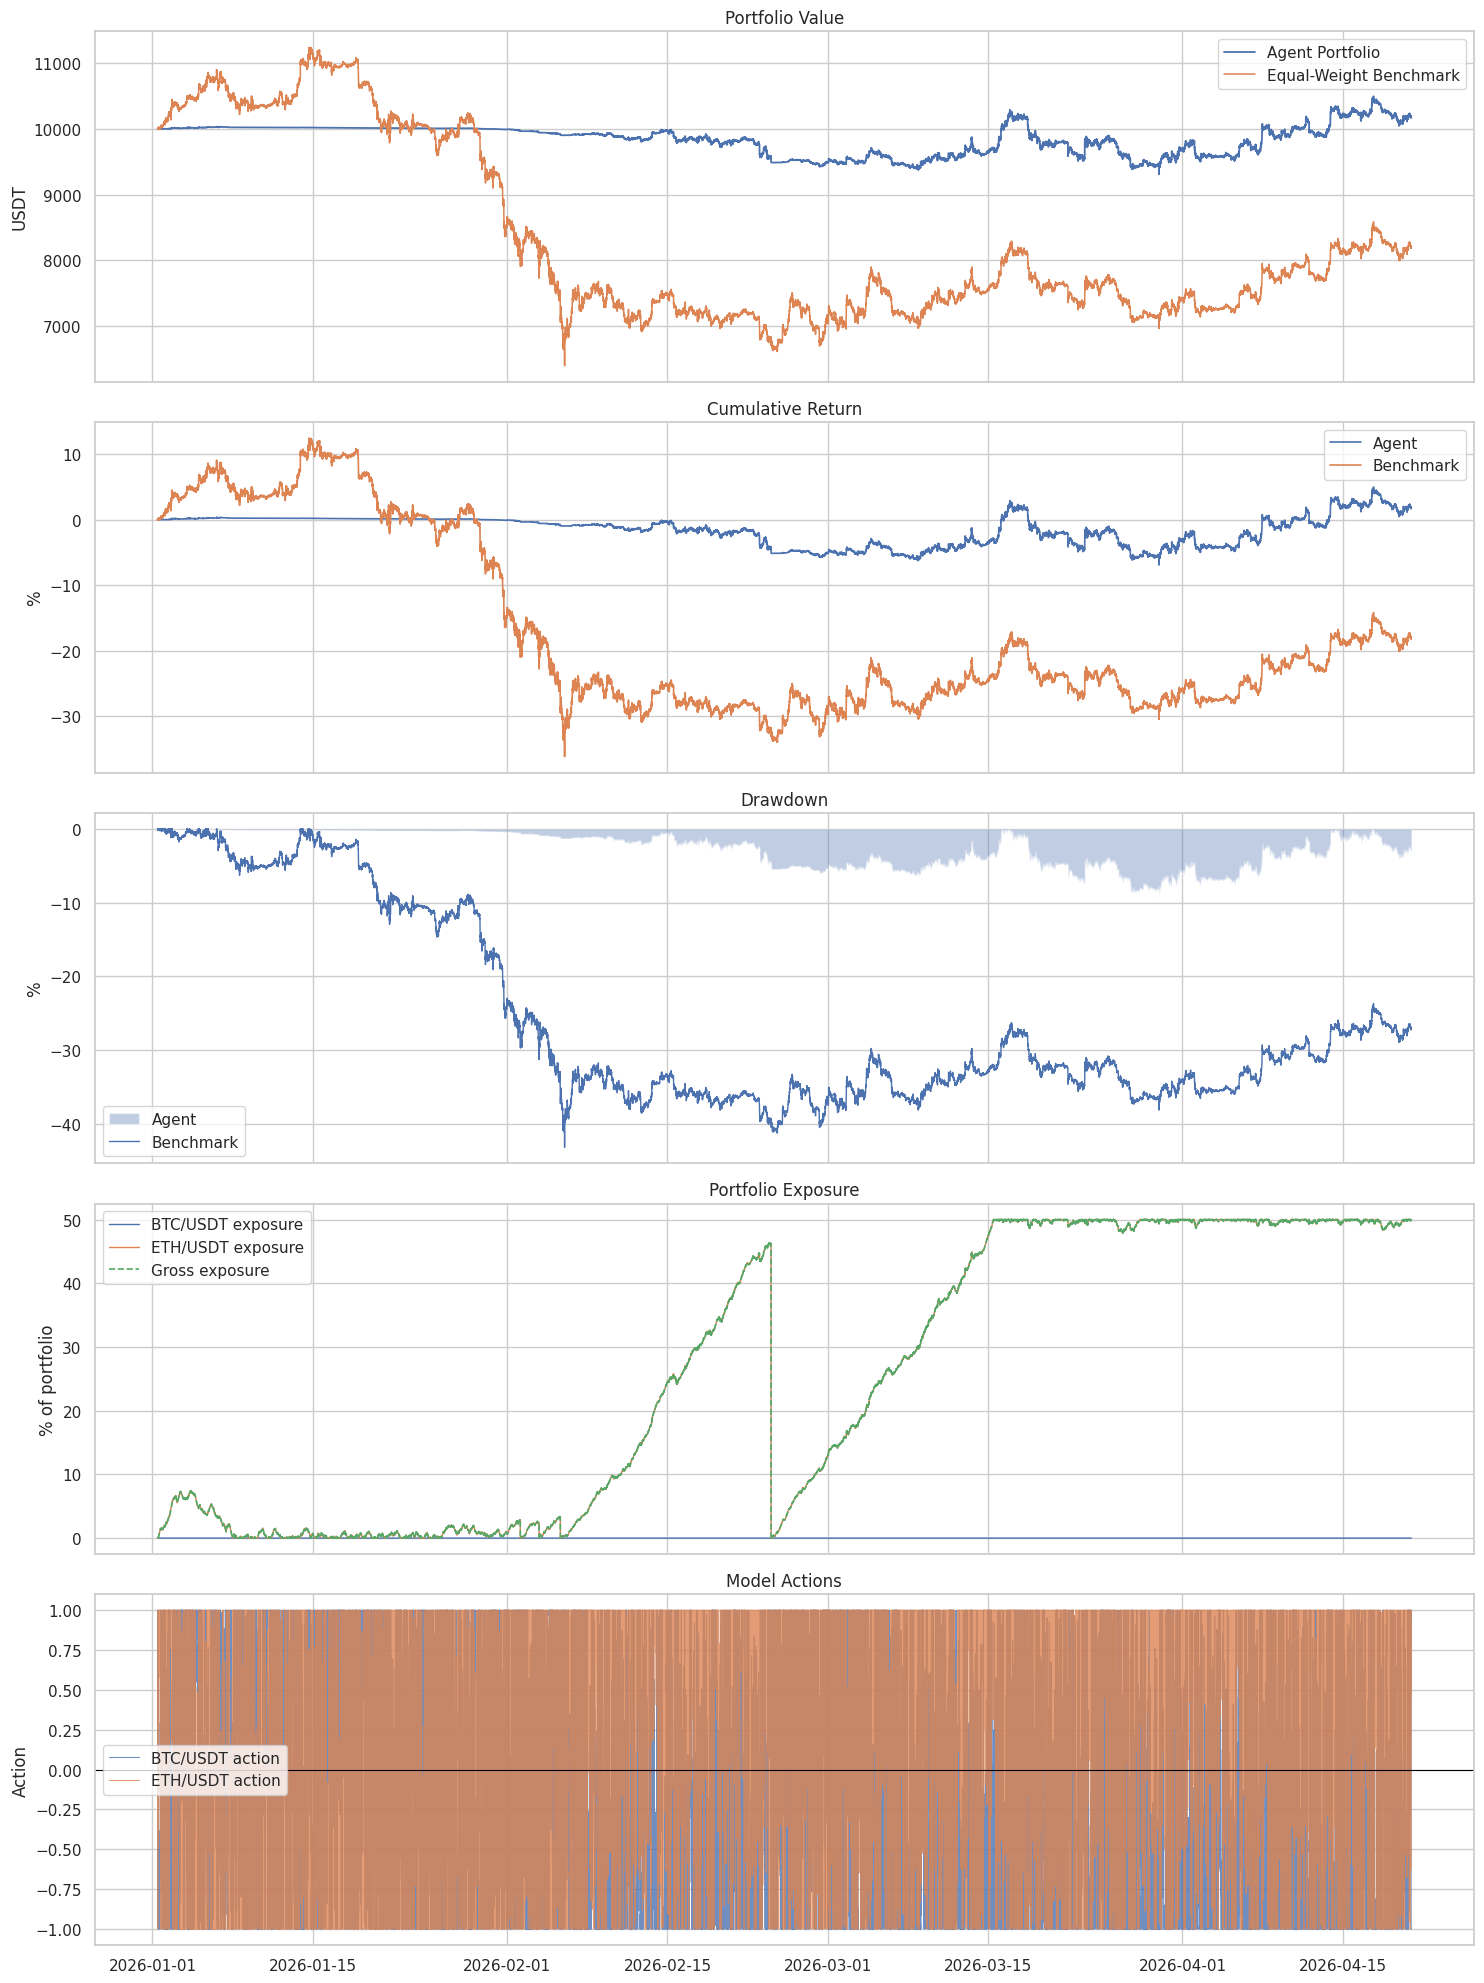

Saved combined analysis plot: /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026/plots/profit_pilot_ppo_5m_t4_test_analysis.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
sns.set_theme(style='whitegrid')

plot_frame = test_results.copy()
plot_frame['datetime'] = pd.to_datetime(plot_frame['datetime'], utc=True)
rolling_window = 12 * 24 * 7
plot_frame['agent_7d_return'] = plot_frame['portfolio_value'] / plot_frame['portfolio_value'].shift(rolling_window) - 1.0
plot_frame['benchmark_7d_return'] = plot_frame['benchmark_value'] / plot_frame['benchmark_value'].shift(rolling_window) - 1.0

fig, axes = plt.subplots(5, 1, figsize=(15, 20), sharex=True)

axes[0].plot(plot_frame['datetime'], plot_frame['portfolio_value'], label='Agent Portfolio', linewidth=1.3)
axes[0].plot(plot_frame['datetime'], plot_frame['benchmark_value'], label='Equal-Weight Benchmark', linewidth=1.1)
axes[0].set_title('Portfolio Value')
axes[0].set_ylabel('USDT')
axes[0].legend()

axes[1].plot(plot_frame['datetime'], plot_frame['agent_cumulative_return'] * 100, label='Agent', linewidth=1.2)
axes[1].plot(plot_frame['datetime'], plot_frame['benchmark_cumulative_return'] * 100, label='Benchmark', linewidth=1.2)
axes[1].set_title('Cumulative Return')
axes[1].set_ylabel('%')
axes[1].legend()

axes[2].fill_between(plot_frame['datetime'], plot_frame['agent_drawdown'] * 100, 0, alpha=0.35, label='Agent')
axes[2].plot(plot_frame['datetime'], plot_frame['benchmark_drawdown'] * 100, label='Benchmark', linewidth=1.0)
axes[2].set_title('Drawdown')
axes[2].set_ylabel('%')
axes[2].legend()

for symbol in SYMBOLS:
    slug = symbol_slug(symbol)
    axes[3].plot(plot_frame['datetime'], plot_frame[f'exposure_{slug}'] * 100, label=f'{symbol} exposure', linewidth=1.0)
axes[3].plot(plot_frame['datetime'], plot_frame['gross_exposure'] * 100, label='Gross exposure', linewidth=1.2, linestyle='--')
axes[3].set_title('Portfolio Exposure')
axes[3].set_ylabel('% of portfolio')
axes[3].legend()

for symbol in SYMBOLS:
    slug = symbol_slug(symbol)
    axes[4].plot(plot_frame['datetime'], plot_frame[f'action_{slug}'], label=f'{symbol} action', linewidth=0.8, alpha=0.8)
axes[4].axhline(0, color='black', linewidth=0.8)
axes[4].set_title('Model Actions')
axes[4].set_ylabel('Action')
axes[4].legend()

plt.tight_layout()
combined_plot_path = PLOT_DIR / f'{MODEL_NAME}_test_analysis.png'
fig.savefig(combined_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved combined analysis plot: {combined_plot_path}')

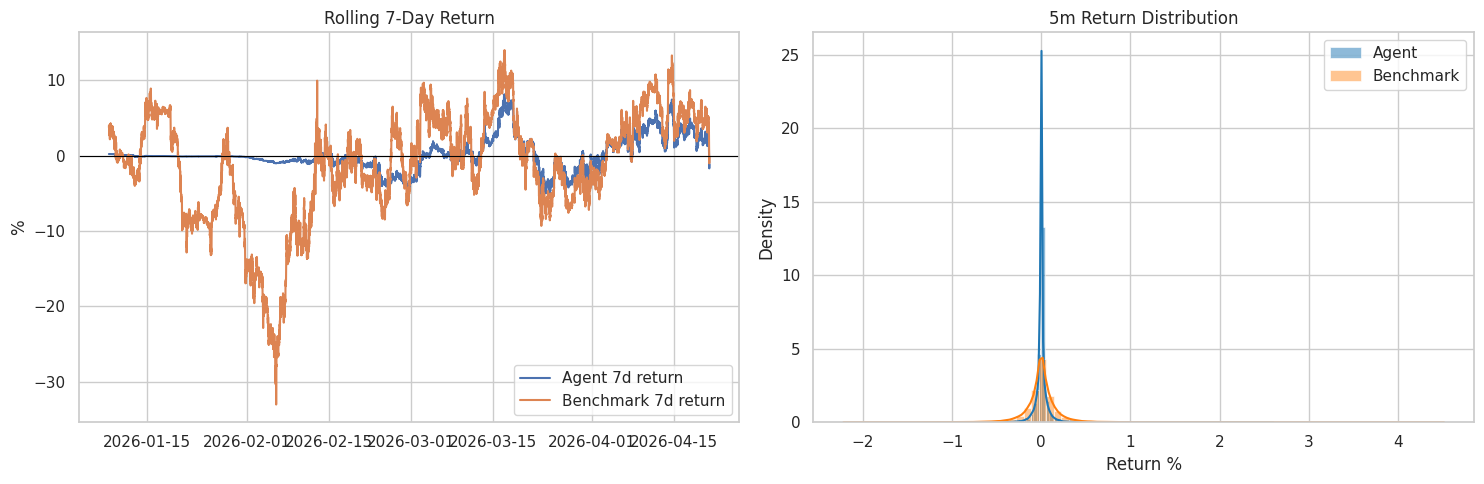

Saved risk diagnostics plot: /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026/plots/profit_pilot_ppo_5m_t4_risk_diagnostics.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(plot_frame['datetime'], plot_frame['agent_7d_return'] * 100, label='Agent 7d return')
axes[0].plot(plot_frame['datetime'], plot_frame['benchmark_7d_return'] * 100, label='Benchmark 7d return')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Rolling 7-Day Return')
axes[0].set_ylabel('%')
axes[0].legend()

sns.histplot(plot_frame['agent_return'] * 100, bins=80, kde=True, ax=axes[1], label='Agent', color='tab:blue', stat='density')
sns.histplot(plot_frame['benchmark_return'] * 100, bins=80, kde=True, ax=axes[1], label='Benchmark', color='tab:orange', stat='density', alpha=0.45)
axes[1].set_title('5m Return Distribution')
axes[1].set_xlabel('Return %')
axes[1].legend()

plt.tight_layout()
risk_plot_path = PLOT_DIR / f'{MODEL_NAME}_risk_diagnostics.png'
fig.savefig(risk_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved risk diagnostics plot: {risk_plot_path}')

## Artifact Summary

Use these files for your report or presentation. The most important output is the out-of-sample metrics JSON plus the combined analysis plot.

In [14]:
artifact_summary = {
    'model_zip': str(MODEL_PATH) + '.zip',
    'training_summary': str(MODEL_DIR / f'{MODEL_NAME}_training_summary.json'),
    'test_results_csv': str(test_csv_path),
    'test_metrics_json': str(metrics_path),
    'combined_analysis_plot': str(combined_plot_path),
    'risk_diagnostics_plot': str(risk_plot_path),
    'train_processed_bundle': str(train_bundle['root']),
    'test_processed_bundle': str(test_bundle['root']),
}
display(pd.DataFrame(artifact_summary.items(), columns=['artifact', 'path']))
with (REPORT_DIR / f'{MODEL_NAME}_artifact_summary.json').open('w', encoding='utf-8') as handle:
    json.dump(artifact_summary, handle, indent=2)

,artifact,path
0,model_zip,/content/drive/MyDrive/ProfitPilot/models/cola...
1,training_summary,/content/drive/MyDrive/ProfitPilot/models/cola...
2,test_results_csv,/content/drive/MyDrive/ProfitPilot/reports/col...
3,test_metrics_json,/content/drive/MyDrive/ProfitPilot/reports/col...
4,combined_analysis_plot,/content/drive/MyDrive/ProfitPilot/reports/col...
5,risk_diagnostics_plot,/content/drive/MyDrive/ProfitPilot/reports/col...
6,train_processed_bundle,/content/drive/MyDrive/ProfitPilot/data/proces...
7,test_processed_bundle,/content/drive/MyDrive/ProfitPilot/data/proces...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Forward Test: Apr 20 to Apr 28

This section tests the already trained model on the fresh period from `2026-04-20 00:00 UTC` to `2026-04-28 00:00 UTC`. It downloads extra warm-up candles before Apr 20 only so the technical indicators and lookback window are ready, but the test portfolio itself starts at Apr 20 with `10,000 USDT` cash and zero holdings.

In [16]:
FORWARD_TEST_START_ISO = '2026-04-20T00:00:00Z'
FORWARD_TEST_END_ISO = '2026-04-28T00:00:00Z'
FORWARD_WARMUP_START_ISO = '2026-04-18T00:00:00Z'

FORWARD_RAW_ROOT = PROJECT_ROOT / 'data' / 'raw_colab_5m_forward_2026_0420_0428'
FORWARD_PROCESSED_ROOT = PROJECT_ROOT / 'data' / 'processed_colab_5m_forward_2026_0420_0428'
FORWARD_REPORT_DIR = REPORT_DIR / 'forward_2026_0420_0428'
FORWARD_PLOT_DIR = FORWARD_REPORT_DIR / 'plots'
for path in [FORWARD_RAW_ROOT, FORWARD_PROCESSED_ROOT, FORWARD_REPORT_DIR, FORWARD_PLOT_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def read_forward_cached_frame(path: Path, start_iso: str, end_iso: str) -> pd.DataFrame | None:
    if not path.exists() or FORCE_REDOWNLOAD:
        return None

    frame = pd.read_csv(path)
    if frame.empty or 'datetime' not in frame.columns:
        return None

    frame['datetime'] = pd.to_datetime(frame['datetime'], utc=True)
    start = pd.Timestamp(start_iso)
    end = pd.Timestamp(end_iso)
    if frame['datetime'].min() <= start and frame['datetime'].max() >= end - pd.Timedelta(minutes=5):
        return frame[(frame['datetime'] >= start) & (frame['datetime'] <= end)].copy()
    return None


def load_or_download_forward_symbol(exchange, exchange_id: str, symbol: str) -> pd.DataFrame:
    target_path = FORWARD_RAW_ROOT / exchange_id / TIMEFRAME / f'{symbol_slug(symbol)}.csv'
    cached = read_forward_cached_frame(target_path, FORWARD_WARMUP_START_ISO, FORWARD_TEST_END_ISO)
    if cached is not None:
        print(f'Using cached forward {symbol} from {exchange_id}: {len(cached):,} rows')
        return cached

    print(f'Downloading forward {symbol} {TIMEFRAME} from {exchange_id}: {FORWARD_WARMUP_START_ISO} to {FORWARD_TEST_END_ISO}')
    frame = fetch_symbol_ohlcv(
        exchange=exchange,
        symbol=symbol,
        timeframe=TIMEFRAME,
        since=FORWARD_WARMUP_START_ISO,
        until=FORWARD_TEST_END_ISO,
        limit=DOWNLOAD_LIMIT,
    )
    frame['datetime'] = pd.to_datetime(frame['datetime'], utc=True)
    saved_path = save_symbol_csv(frame, FORWARD_RAW_ROOT, exchange_id, TIMEFRAME, symbol)
    print(f'Saved {len(frame):,} rows to {saved_path}')
    return frame


def download_forward_frames() -> dict[str, pd.DataFrame]:
    forward_exchange_ids = [EXCHANGE_ID] + [exchange_id for exchange_id in EXCHANGE_IDS if exchange_id != EXCHANGE_ID]
    forward_errors = {}

    for candidate_exchange_id in forward_exchange_ids:
        print(f'\nTrying forward-test exchange: {candidate_exchange_id}')
        exchange = create_market_data_exchange(candidate_exchange_id)
        try:
            exchange.load_markets()
            available_symbols = set(exchange.symbols or [])
            missing_symbols = [symbol for symbol in SYMBOLS if symbol not in available_symbols]
            if missing_symbols:
                raise ValueError(f'{candidate_exchange_id} does not list these symbols: {missing_symbols}')

            frames = {
                symbol: load_or_download_forward_symbol(exchange, candidate_exchange_id, symbol)
                for symbol in SYMBOLS
            }
            print(f'Using forward-test exchange: {candidate_exchange_id}')
            return frames
        except Exception as exc:
            error_message = f'{type(exc).__name__}: {str(exc)}'
            forward_errors[candidate_exchange_id] = error_message
            print(f'{candidate_exchange_id} failed: {error_message[:500]}')
        finally:
            if hasattr(exchange, 'close'):
                exchange.close()

    display(pd.DataFrame(forward_errors.items(), columns=['exchange', 'error']))
    raise RuntimeError('No exchange could download the Apr 20 to Apr 28 forward-test data.')


def slice_bundle_to_start_at(bundle: dict, start_iso: str) -> dict:
    timestamps = pd.to_datetime(bundle['timestamps']['datetime'], utc=True).reset_index(drop=True)
    start_timestamp = pd.Timestamp(start_iso)
    start_index = int(timestamps.searchsorted(start_timestamp, side='left'))
    slice_start = start_index - LOOKBACK + 1
    if slice_start < 0:
        raise ValueError('Not enough warm-up rows before the forward test start. Move FORWARD_WARMUP_START_ISO earlier.')

    sliced_timestamps = timestamps.iloc[slice_start:].reset_index(drop=True)
    first_eval_timestamp = sliced_timestamps.iloc[LOOKBACK - 1]
    if first_eval_timestamp < start_timestamp:
        raise ValueError(f'Forward test would start before requested date: {first_eval_timestamp}')

    sliced_bundle = {
        'root': bundle['root'],
        'price_array': bundle['price_array'][slice_start:],
        'tech_array': bundle['tech_array'][slice_start:],
        'timestamps': pd.DataFrame({'datetime': sliced_timestamps.astype(str)}),
        'metadata': dict(bundle['metadata']),
    }
    sliced_bundle['metadata']['forward_requested_start'] = start_iso
    sliced_bundle['metadata']['forward_first_eval_timestamp'] = str(first_eval_timestamp)
    return sliced_bundle


forward_symbol_frames = download_forward_frames()
forward_warm_bundle, _ = build_normalized_feature_bundle(
    forward_symbol_frames,
    FORWARD_PROCESSED_ROOT,
    FORWARD_WARMUP_START_ISO,
    FORWARD_TEST_END_ISO,
    label='forward_warmup_2026_0418_0428',
    normalization_stats=train_norm_stats,
)
forward_test_bundle = slice_bundle_to_start_at(forward_warm_bundle, FORWARD_TEST_START_ISO)

if 'model' not in globals():
    model_class = RecurrentPPO if USE_LSTM else PPO
    model = model_class.load(MODEL_PATH, device=DEVICE)

forward_results = evaluate_trading_model(model, forward_test_bundle, label='forward_2026_0420_0428')
forward_results = add_curve_columns(forward_results)

forward_csv_path = FORWARD_REPORT_DIR / f'{MODEL_NAME}_forward_2026_0420_0428_results.csv'
forward_results.to_csv(forward_csv_path, index=False)

forward_agent_metrics = summarize_strategy(forward_results, 'portfolio_value', 'agent_return', 'agent_drawdown')
forward_benchmark_metrics = summarize_strategy(forward_results, 'benchmark_value', 'benchmark_return', 'benchmark_drawdown')
forward_holding_cols = [f'holding_{symbol_slug(symbol)}' for symbol in SYMBOLS]
forward_trade_events = int((forward_results[forward_holding_cols].diff().abs().sum(axis=1) > 1e-8).sum())
forward_agent_metrics.update({
    'total_fees': float(forward_results['total_fees'].sum()),
    'trade_events': forward_trade_events,
    'mean_gross_exposure_pct': float(forward_results['gross_exposure'].mean() * 100),
    'risk_halted': bool(forward_results['risk_halted'].any()),
})
forward_benchmark_metrics.update({
    'total_fees': 0.0,
    'trade_events': 0,
    'mean_gross_exposure_pct': 100.0,
    'risk_halted': False,
})

forward_metrics_df = pd.DataFrame({
    'agent': forward_agent_metrics,
    'equal_weight_benchmark': forward_benchmark_metrics,
}).T
forward_metrics_df['alpha_vs_benchmark_pct'] = (
    forward_metrics_df['total_return_pct'] - forward_metrics_df.loc['equal_weight_benchmark', 'total_return_pct']
)

forward_metrics_path = FORWARD_REPORT_DIR / f'{MODEL_NAME}_forward_2026_0420_0428_metrics.json'
forward_metrics_payload = json.loads(forward_metrics_df.reset_index().rename(columns={'index': 'strategy'}).to_json(orient='records'))
with forward_metrics_path.open('w', encoding='utf-8') as handle:
    json.dump(forward_metrics_payload, handle, indent=2)

print(f'Forward test actual start: {forward_results["datetime"].iloc[0]}')
print(f'Forward test actual end:   {forward_results["datetime"].iloc[-1]}')
print(f'Saved forward results: {forward_csv_path}')
print(f'Saved forward metrics: {forward_metrics_path}')
display(forward_metrics_df.round(4))


Trying forward-test exchange: binanceus
Saved 2,881 rows to /content/drive/MyDrive/ProfitPilot/data/raw_colab_5m_forward_2026_0420_0428/binanceus/5m/btc_usdt.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saved 2,881 rows to /content/drive/MyDrive/ProfitPilot/data/raw_colab_5m_forward_2026_0420_0428/binanceus/5m/eth_usdt.csv
Using forward-test exchange: binanceus


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Forward test actual start: 2026-04-20 00:00:00+00:00
Forward test actual end:   2026-04-28 00:00:00+00:00
Saved forward results: /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026/forward_2026_0420_0428/profit_pilot_ppo_5m_t4_forward_2026_0420_0428_results.csv
Saved forward metrics: /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026/forward_2026_0420_0428/profit_pilot_ppo_5m_t4_forward_2026_0420_0428_metrics.json


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,initial_value,final_value,total_return_pct,annualized_return_pct,annualized_volatility_pct,sharpe,sortino,max_drawdown_pct,calmar,win_rate_pct,total_fees,trade_events,mean_gross_exposure_pct,risk_halted,alpha_vs_benchmark_pct
agent,10000.0,9969.666016,-0.30334,-12.943177,4.765537,-2.883478,-3.208587,0.964604,-13.41812,39.305857,3.85486,2158,9.568412,False,-3.063262
equal_weight_benchmark,10000.0,10275.992188,2.759922,246.305427,40.236379,3.286992,4.156818,4.742561,51.935108,48.02603,0.0,0,100.0,False,0.0


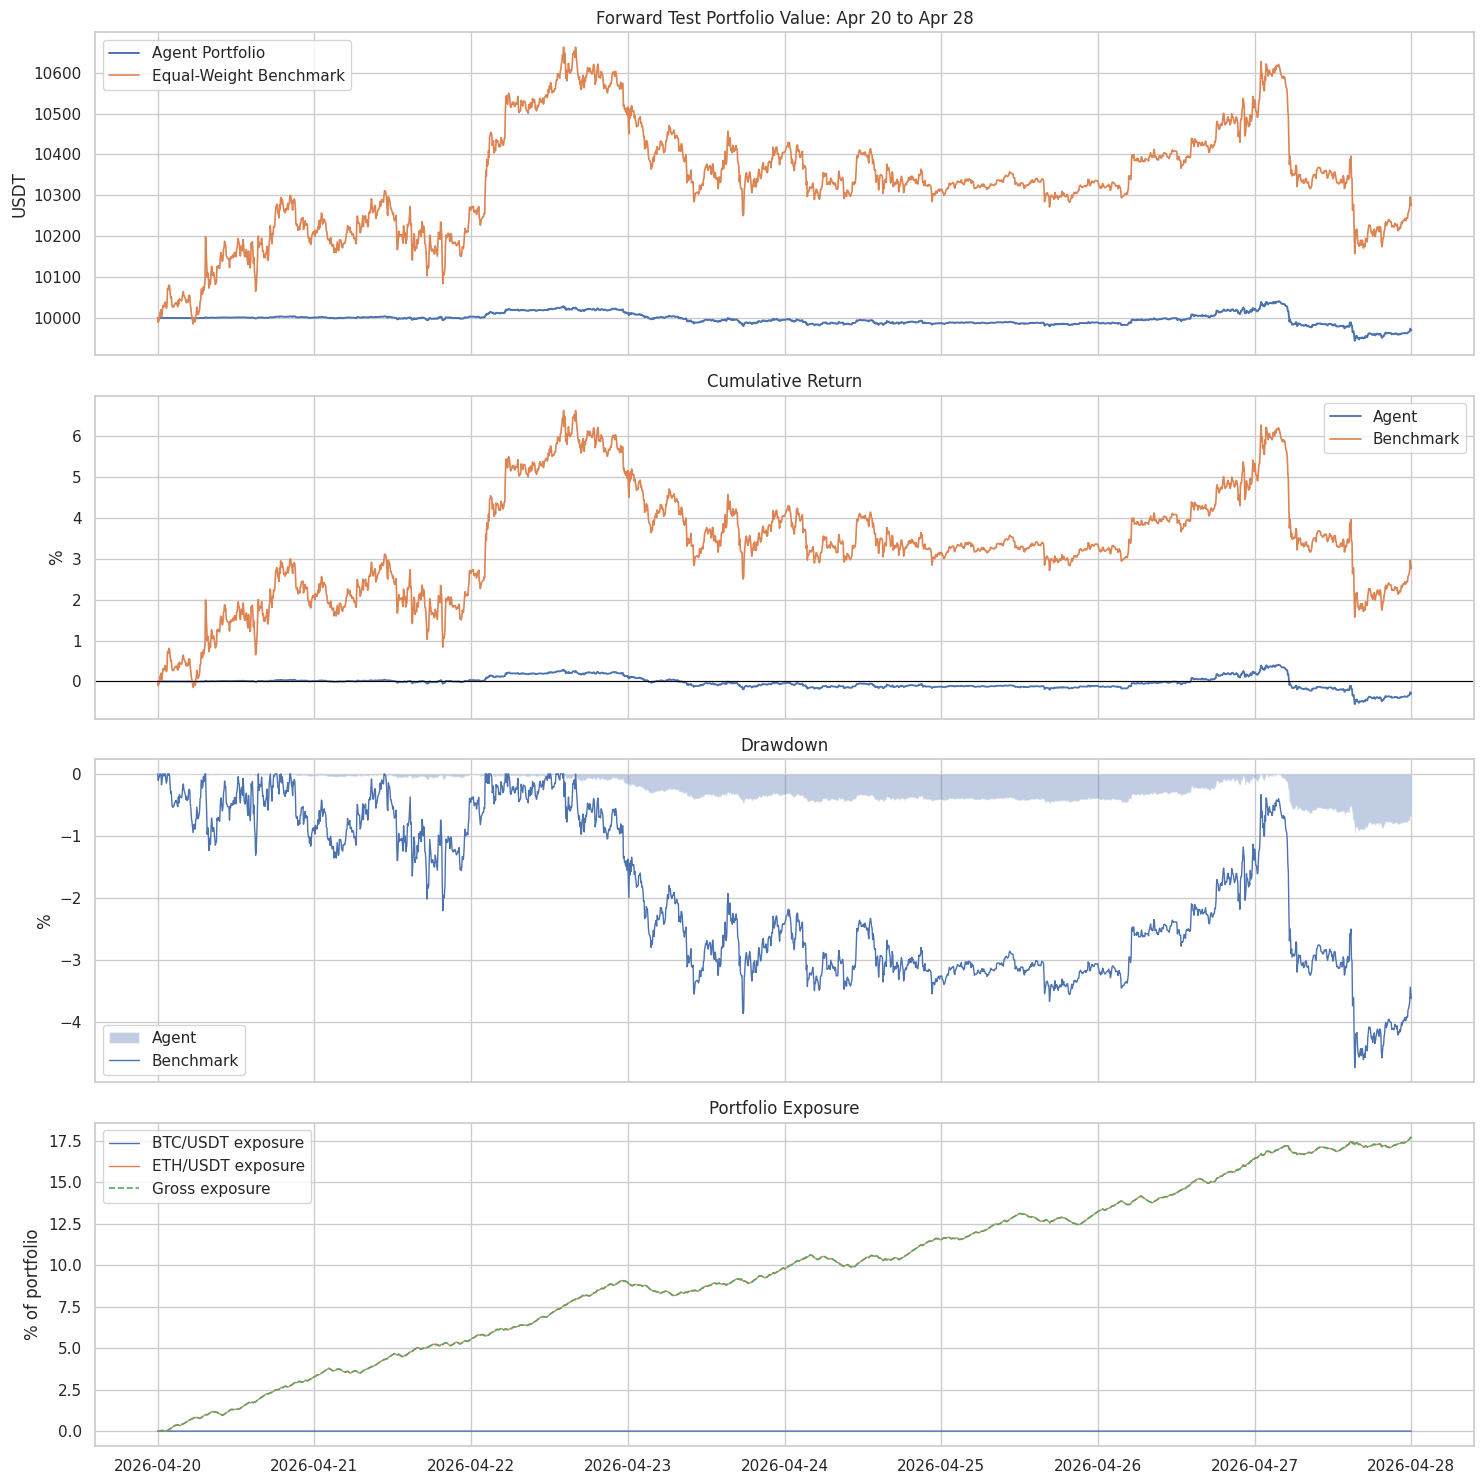

Saved forward test plot: /content/drive/MyDrive/ProfitPilot/reports/colab_5m_2024_2026/forward_2026_0420_0428/plots/profit_pilot_ppo_5m_t4_forward_2026_0420_0428_analysis.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
forward_plot_frame = forward_results.copy()
forward_plot_frame['datetime'] = pd.to_datetime(forward_plot_frame['datetime'], utc=True)
forward_rolling_window = min(12 * 24, max(12, len(forward_plot_frame) // 3))
forward_plot_frame['agent_rolling_return'] = forward_plot_frame['portfolio_value'] / forward_plot_frame['portfolio_value'].shift(forward_rolling_window) - 1.0
forward_plot_frame['benchmark_rolling_return'] = forward_plot_frame['benchmark_value'] / forward_plot_frame['benchmark_value'].shift(forward_rolling_window) - 1.0

fig, axes = plt.subplots(4, 1, figsize=(15, 15), sharex=True)

axes[0].plot(forward_plot_frame['datetime'], forward_plot_frame['portfolio_value'], label='Agent Portfolio', linewidth=1.4)
axes[0].plot(forward_plot_frame['datetime'], forward_plot_frame['benchmark_value'], label='Equal-Weight Benchmark', linewidth=1.2)
axes[0].set_title('Forward Test Portfolio Value: Apr 20 to Apr 28')
axes[0].set_ylabel('USDT')
axes[0].legend()

axes[1].plot(forward_plot_frame['datetime'], forward_plot_frame['agent_cumulative_return'] * 100, label='Agent', linewidth=1.3)
axes[1].plot(forward_plot_frame['datetime'], forward_plot_frame['benchmark_cumulative_return'] * 100, label='Benchmark', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Cumulative Return')
axes[1].set_ylabel('%')
axes[1].legend()

axes[2].fill_between(forward_plot_frame['datetime'], forward_plot_frame['agent_drawdown'] * 100, 0, alpha=0.35, label='Agent')
axes[2].plot(forward_plot_frame['datetime'], forward_plot_frame['benchmark_drawdown'] * 100, label='Benchmark', linewidth=1.0)
axes[2].set_title('Drawdown')
axes[2].set_ylabel('%')
axes[2].legend()

for symbol in SYMBOLS:
    slug = symbol_slug(symbol)
    axes[3].plot(forward_plot_frame['datetime'], forward_plot_frame[f'exposure_{slug}'] * 100, label=f'{symbol} exposure', linewidth=1.0)
axes[3].plot(forward_plot_frame['datetime'], forward_plot_frame['gross_exposure'] * 100, label='Gross exposure', linewidth=1.2, linestyle='--')
axes[3].set_title('Portfolio Exposure')
axes[3].set_ylabel('% of portfolio')
axes[3].legend()

plt.tight_layout()
forward_plot_path = FORWARD_PLOT_DIR / f'{MODEL_NAME}_forward_2026_0420_0428_analysis.png'
fig.savefig(forward_plot_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved forward test plot: {forward_plot_path}')

## Optional: Final Full-Window Retrain

Run this only after the out-of-sample test looks good. It trains a final artifact on the complete requested data window from `2024-01-01` through `2026-04-20`. This final model is not used for the worthiness test because it has seen the test period.

In [15]:
if RUN_FINAL_FULL_WINDOW_RETRAIN:
    full_frames = split_symbol_frames(full_symbol_frames, DATA_START_ISO, DATA_END_ISO, inclusive_end=True)
    full_bundle, _ = build_normalized_feature_bundle(
        full_frames,
        PROCESSED_FULL_ROOT,
        DATA_START_ISO,
        DATA_END_ISO,
        label='full_2024_0101_2026_0420',
    )
    full_env = make_vec_env(full_bundle)
    final_name = f'{MODEL_NAME}_full_window'
    final_path = MODEL_DIR / final_name
    if USE_LSTM:
        final_model = RecurrentPPO(
            'MlpLstmPolicy',
            env=full_env,
            verbose=1,
            learning_rate=3e-4,
            n_steps=4096,
            batch_size=1024,
            gamma=0.995,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.01,
            device=DEVICE,
        )
    else:
        final_model = PPO(
            'MlpPolicy',
            env=full_env,
            verbose=1,
            learning_rate=3e-4,
            n_steps=4096,
            batch_size=1024,
            gamma=0.995,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.01,
            device=DEVICE,
            policy_kwargs={'net_arch': [256, 256]},
        )
    final_model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
    final_model.save(final_path)
    full_env.close()
    print(f'Saved final full-window model: {final_path}.zip')
else:
    print('Skipped final full-window retrain. Set RUN_FINAL_FULL_WINDOW_RETRAIN = True after the test metrics are acceptable.')

Skipped final full-window retrain. Set RUN_FINAL_FULL_WINDOW_RETRAIN = True after the test metrics are acceptable.
